In [35]:
from sklearn.preprocessing import StandardScaler
from utils.evaluation import *
from utils.load_data import load_processed_data
from models.dnn import DNN
from models.linear_regression import LinearRegressionSklearn 
import torch
from torch.utils.data import DataLoader, Dataset

## Load data

In [36]:
data_path = '../data/processed'
X_train, X_val, X_test, y_train, y_val, y_test = load_processed_data(data_path)

X_train shape: torch.Size([2132, 84]), y_train shape: torch.Size([2132, 1])
X_val shape: torch.Size([457, 84]), y_val shape: torch.Size([457, 1])
X_test shape: torch.Size([458, 84]), y_test shape: torch.Size([458, 1])


In [37]:
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [38]:
batch_size = 128

train_dataset = CustomDataset(X_train, y_train)
val_dataset = CustomDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

## Training and Evaluation

#### Hyperparameters

In [39]:
epochs = 500
learning_rate = 0.001
dropout = 0.1
batch_norm = True
l2_lambda = 1e-4
grad_clip = False
activation = 'relu'

In [40]:
def pipeline(
        model, 
        epochs=50, 
        verbose=True, 
        early_stopping=False, 
        patience=10, 
        grad_clip=True, 
        title=None,
):
    train_losses, val_losses = model.fit(
        train_loader, 
        val_loader, 
        epochs=epochs, 
        verbose=verbose, 
        early_stopping=early_stopping, 
        patience=patience, 
        grad_clip=grad_clip
    )
    test_model(model, X_test, y_test)
    if title is None:
        title = f'{model.__class__.__name__}'
    plot_loss(train_losses, val_losses, log=True, title=title)

### Linear Regression

In [41]:
lr = LinearRegressionSklearn()
lr.fit(X_train, y_train)
test_model(lr, X_test, y_test)


=========== Model Evaluation ===========
Mean Absolute Error (MAE): 9.5724
Mean Squared Error (MSE): 171.9365
R^2 Score: 0.7835


### DNN-16

In [42]:
dnn_16 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[16],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda,
    activation=activation
)
dnn_16.model

Sequential(
  (0): Linear(in_features=84, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
)

Epoch [50/500], Train Loss: 16872.7495, Val Loss: 15974.1355
Epoch [100/500], Train Loss: 4427.9513, Val Loss: 4757.8455
Epoch [150/500], Train Loss: 1416.2609, Val Loss: 1619.2162
Epoch [200/500], Train Loss: 669.1646, Val Loss: 799.9149
Epoch [250/500], Train Loss: 432.5116, Val Loss: 550.0607
Epoch [300/500], Train Loss: 341.5231, Val Loss: 443.4115
Epoch [350/500], Train Loss: 293.3056, Val Loss: 390.7981
Epoch [400/500], Train Loss: 262.9367, Val Loss: 363.1109
Epoch [450/500], Train Loss: 241.5063, Val Loss: 344.3580
Epoch [500/500], Train Loss: 228.0046, Val Loss: 328.8615

=========== Model Evaluation ===========
Mean Absolute Error (MAE): 13.4536
Mean Squared Error (MSE): 346.1906
R^2 Score: 0.5641


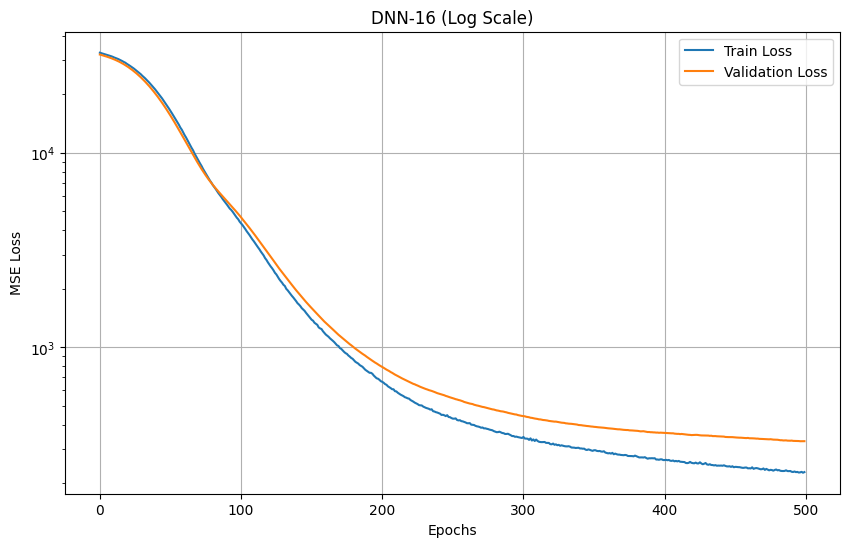

In [43]:
pipeline(dnn_16, epochs=epochs, title='DNN-16')

## DNN-30-8

In [44]:
dnn_30_8 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[30, 8],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda,
    activation=activation
)
dnn_30_8.model

Sequential(
  (0): Linear(in_features=84, out_features=30, bias=True)
  (1): ReLU()
  (2): Linear(in_features=30, out_features=8, bias=True)
  (3): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): ReLU()
  (5): Dropout(p=0.1, inplace=False)
  (6): Linear(in_features=8, out_features=1, bias=True)
)

Epoch [50/500], Train Loss: 22352.1722, Val Loss: 21525.1069
Epoch [100/500], Train Loss: 5501.2502, Val Loss: 4769.7950
Epoch [150/500], Train Loss: 1612.0772, Val Loss: 468.6443
Epoch [200/500], Train Loss: 1466.7396, Val Loss: 390.5297
Epoch [250/500], Train Loss: 1282.6661, Val Loss: 381.8139
Epoch [300/500], Train Loss: 1130.7583, Val Loss: 378.7730
Epoch [350/500], Train Loss: 1201.8184, Val Loss: 366.6313
Epoch [400/500], Train Loss: 1016.4964, Val Loss: 358.2954
Epoch [450/500], Train Loss: 929.8950, Val Loss: 354.4699
Epoch [500/500], Train Loss: 869.9481, Val Loss: 349.9206

=========== Model Evaluation ===========
Mean Absolute Error (MAE): 15.0197
Mean Squared Error (MSE): 404.8232
R^2 Score: 0.4903


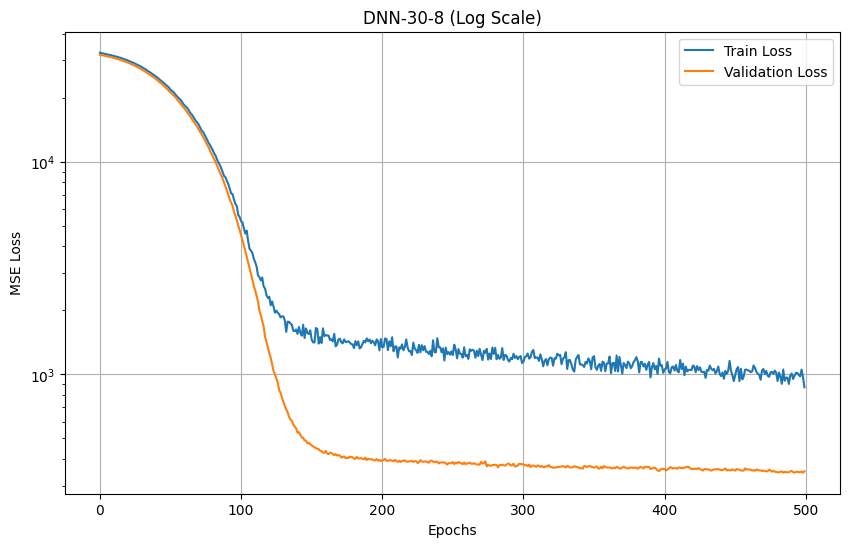

In [45]:
pipeline(dnn_30_8, epochs=epochs, title='DNN-30-8')

## DNN-30-16-8

In [46]:
dnn_30_16_8 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[30, 16, 8],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda,
    activation=activation
)
dnn_30_16_8.model

Sequential(
  (0): Linear(in_features=84, out_features=30, bias=True)
  (1): ReLU()
  (2): Linear(in_features=30, out_features=16, bias=True)
  (3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): ReLU()
  (5): Dropout(p=0.1, inplace=False)
  (6): Linear(in_features=16, out_features=8, bias=True)
  (7): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): ReLU()
  (9): Dropout(p=0.1, inplace=False)
  (10): Linear(in_features=8, out_features=1, bias=True)
)

Epoch [50/500], Train Loss: 23909.2456, Val Loss: 23269.3721
Epoch [100/500], Train Loss: 7595.0051, Val Loss: 6514.9503
Epoch [150/500], Train Loss: 2353.9579, Val Loss: 725.7224
Epoch [200/500], Train Loss: 2018.9117, Val Loss: 496.1351
Epoch [250/500], Train Loss: 1684.7575, Val Loss: 439.3854
Epoch [300/500], Train Loss: 1614.3995, Val Loss: 419.7397
Epoch [350/500], Train Loss: 1410.0478, Val Loss: 418.4146
Epoch [400/500], Train Loss: 1455.2030, Val Loss: 393.8429
Epoch [450/500], Train Loss: 1423.1397, Val Loss: 400.6771
Epoch [500/500], Train Loss: 1303.0465, Val Loss: 397.6015

=========== Model Evaluation ===========
Mean Absolute Error (MAE): 15.4940
Mean Squared Error (MSE): 440.7611
R^2 Score: 0.4450


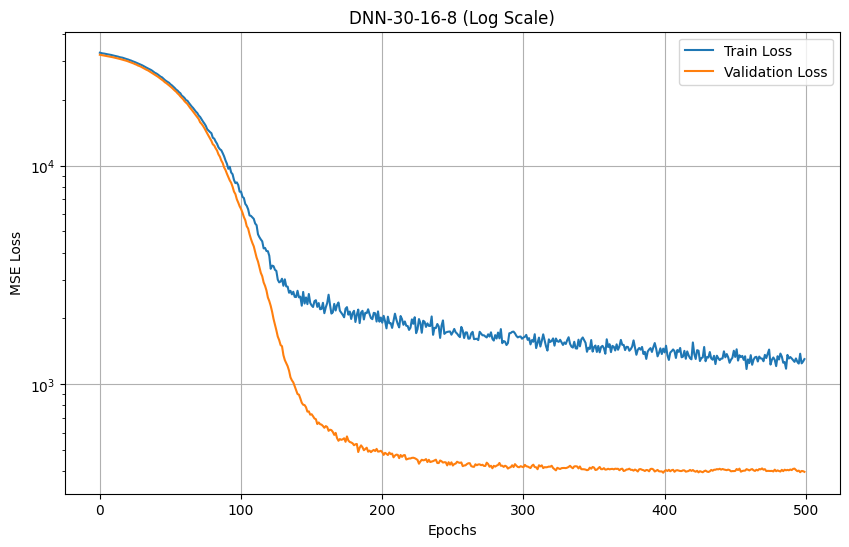

In [47]:
pipeline(dnn_30_16_8, epochs=epochs, title='DNN-30-16-8')

## DNN-30-16-8-4

In [48]:
dnn_30_16_8_4 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[30, 16, 8, 4],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda,
    activation=activation
)
dnn_30_16_8_4.model

Sequential(
  (0): Linear(in_features=84, out_features=30, bias=True)
  (1): ReLU()
  (2): Linear(in_features=30, out_features=16, bias=True)
  (3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): ReLU()
  (5): Dropout(p=0.1, inplace=False)
  (6): Linear(in_features=16, out_features=8, bias=True)
  (7): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): ReLU()
  (9): Dropout(p=0.1, inplace=False)
  (10): Linear(in_features=8, out_features=4, bias=True)
  (11): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (12): ReLU()
  (13): Dropout(p=0.1, inplace=False)
  (14): Linear(in_features=4, out_features=1, bias=True)
)

Epoch [50/500], Train Loss: 24054.5682, Val Loss: 23781.0791
Epoch [100/500], Train Loss: 8618.2957, Val Loss: 8151.1469
Epoch [150/500], Train Loss: 2124.7165, Val Loss: 767.1470
Epoch [200/500], Train Loss: 1815.2365, Val Loss: 494.5475
Epoch [250/500], Train Loss: 1851.7573, Val Loss: 468.7536
Epoch [300/500], Train Loss: 1625.5491, Val Loss: 454.1728
Epoch [350/500], Train Loss: 1629.9877, Val Loss: 443.6540
Epoch [400/500], Train Loss: 1544.0233, Val Loss: 444.4179
Epoch [450/500], Train Loss: 1554.6023, Val Loss: 459.8692
Epoch [500/500], Train Loss: 1406.2479, Val Loss: 451.8648

=========== Model Evaluation ===========
Mean Absolute Error (MAE): 17.1909
Mean Squared Error (MSE): 516.8232
R^2 Score: 0.3492


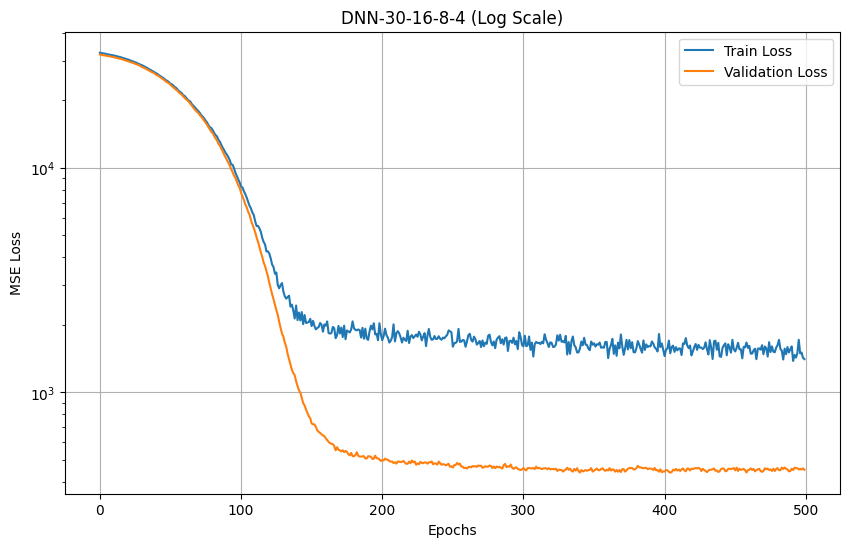

In [49]:
pipeline(dnn_30_16_8_4, epochs=epochs, title='DNN-30-16-8-4')

## Custom DNN

In [50]:
custom_dnn = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[64, 32, 16, 8],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda,
    activation=activation
)
custom_dnn.model

Sequential(
  (0): Linear(in_features=84, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): ReLU()
  (5): Dropout(p=0.1, inplace=False)
  (6): Linear(in_features=32, out_features=16, bias=True)
  (7): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): ReLU()
  (9): Dropout(p=0.1, inplace=False)
  (10): Linear(in_features=16, out_features=8, bias=True)
  (11): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (12): ReLU()
  (13): Dropout(p=0.1, inplace=False)
  (14): Linear(in_features=8, out_features=1, bias=True)
)

Epoch [50/500], Train Loss: 23757.7610, Val Loss: 23195.2373
Epoch [100/500], Train Loss: 7870.7730, Val Loss: 7195.5297
Epoch [150/500], Train Loss: 1488.2619, Val Loss: 571.0854
Epoch [200/500], Train Loss: 1253.8054, Val Loss: 435.0135
Epoch [250/500], Train Loss: 1303.7103, Val Loss: 416.2756
Epoch [300/500], Train Loss: 1198.1297, Val Loss: 400.4353
Epoch [350/500], Train Loss: 1271.4556, Val Loss: 406.3022
Epoch [400/500], Train Loss: 1099.2466, Val Loss: 411.2878
Epoch [450/500], Train Loss: 1082.2115, Val Loss: 403.4647
Epoch [500/500], Train Loss: 1018.5800, Val Loss: 399.4223

=========== Model Evaluation ===========
Mean Absolute Error (MAE): 15.5214
Mean Squared Error (MSE): 441.1242
R^2 Score: 0.4446


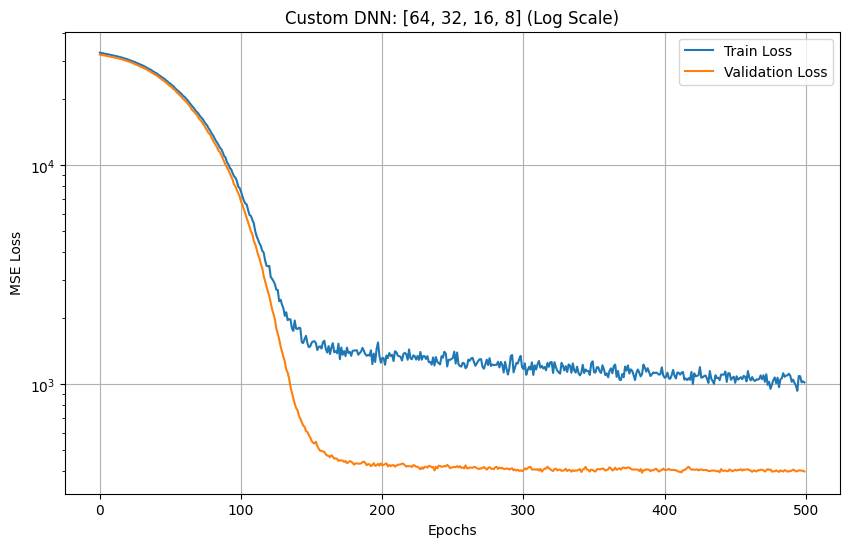

In [51]:
pipeline(custom_dnn, epochs=epochs, title='Custom DNN: [64, 32, 16, 8]')